In [ ]:
Lectures 11-12: Cycles

In [14]:
nb_list = !jupyter notebook list
server = [l for l in nb_list if 'eos423' in l][0].split(' :: ')[0]
prefix = server.split('?')[0]
token = server.split('?')[1]
notebook = 'Lectures14-15_Cycles.ipynb'
url = prefix+'notebooks/'+notebook+'?'+token
!decktape -s '1920x1080' rise $url pdf_slides/Lectures14-15_Cycles.pdf

Loading page http://localhost:8888/notebooks/Lectures14-15_Cycles.ipynb?token=5937d7ea442aade7dc27bf992142d25f4863f0a71809c743 ...
actions jupyter-notebook:find-and-replace does not exist, still binding it in case it will be defined later...
load_extensions {
  '0': 'nbextensions_configurator/config_menu/main',
  '1': 'contrib_nbextensions_help_item/main',
  '2': 'rise/main',
  '3': 'jupyter-js-widgets/extension',
  '4': 'jupyter-black-master/jupyter-black',
  '5': 'toc2/main',
  '6': 'hide_code/hide_code',
  '7': 'hide_input/main',
  '8': 'codefolding/main',
  '9': 'splitcell/splitcell'
}
Loaded moment locale en-gb
Failed to load resource: the server responded with a status of 404 (Not Found)
HTML Sanitizer div.style changed {
  change: 'changed',
  tagName: 'div',
  attribName: 'style',
  oldValue: 'background: url(images/cycles_intro/Elatina_big.jpg) 50% 50% no-repeat;\n' +
    '  width: 100vw;\n' +
    '  height: 30vh; background-size: 100%;',
  newValue: 'background: url("images/c

Session: kernel_created (757409a6-36b9-41ce-97e6-f4a78e9e7e22)
Starting WebSockets: ws://localhost:8888/api/kernels/aab09cf4-d1cc-4d39-a0db-4a2f7dba0be6
Failed to load extension: [ 'nbextensions/hide_code/hide_code' ] {
  requireType: 'scripterror',
  requireModules: [ 'nbextensions/hide_code/hide_code' ],
  originalError: { isTrusted: true }
}
Loading extension: nbextensions_configurator/config_menu/main
Loading extension: contrib_nbextensions_help_item/main
Loading extension: rise/main
Loading extension: hide_input/main
Loading extension: splitcell/splitcell
Kernel: kernel_connected (aab09cf4-d1cc-4d39-a0db-4a2f7dba0be6)
Loading extension: jupyter-js-widgets/extension
Loading extension: jupyter-black-master/jupyter-black
Failed to load resource: the server responded with a status of 404 (Not Found)
Loading extension: toc2/main
[toc2] Notebook fully loaded -- toc2 initialized 
Widgets are not available.  Please install widgetsnbextension or ipywidgets 4.0
Loading extension: codefoldin

<center><div style="background: url(images/cycles_intro/Elatina_big.jpg) 50% 50% no-repeat;
  width: 100vw;
  height: 30vh; background-size: 100%;">
</div></center>

# Lectures 11-12: Cycles

<div style='font-size:25px'>  
    
1. Quantitative correlation
2. An example from our model
3. Enter cyclostratigraphy
4. How to identify a cycle
5. Fourier Transforms
    
</div>

<div style='font-size:25px'> <i>We acknowledge and respect the lək̓ʷəŋən peoples on whose traditional territory the university stands and the Songhees, Esquimalt and W̱SÁNE&#262; peoples whose historical relationships with the land continue to this day.</i></div>

# Brief return to Wheeler diagrams
<center>
    <div style='width:100wh;'>
	    <img src="images/cycles_intro/wheeler/chronostrat_rsl.png" style='width:100wh'>
    </div>
</center>

# Brief return to Wheeler diagrams
<center>
    <div style='width:100wh;'>
	    <img src="images/cycles_intro/wheeler/chronostrat_lith.png" style='width:100wh'>
    </div>
</center>

# Brief return to Wheeler diagrams
<center>
    <div style='width:100wh;'>
	    <img src="images/cycles_intro/wheeler/lithostrat.png" style='width:100wh'>
    </div>
</center>

# Correlating sequences: an example from our model
<center>
    <div style='width:100wh;'>
	    <img src="images/cycles_intro/correlation_game/corr_game1.jpg" style='width:100wh'>
    </div>
</center>

# Correlating sequences: an example from our model
<center>
    <div style='width:100wh;'>
	    <img src="images/cycles_intro/correlation_game/corr_game2.jpg" style='width:100wh'>
    </div>
</center>

# Correlating sequences: an example from our model
<center>
    <div style='width:50wh;'>
	    <img src="images/cycles_intro/correlation_game/rsl_history1.png" style='width:50wh'>
    </div>
</center>

# Correlating sequences: an example from our model
<center>
    <div style='width:50wh;'>
	    <img src="images/cycles_intro/correlation_game/rsl_history2.png" style='width:50wh'>
    </div>
</center>

# Why do the sea-level cycles look funny?

<center>
    <div style='width:100wh;'>
	    <img src="images/cycles_intro/correlation_game/corr_game3.jpg" style='width:100wh'>
    </div>
</center>

# Why do the sea-level cycles look funny?

<center>
    <div style='width:100wh;'>
	    <img src="images/cycles_intro/correlation_game/corr_game4.jpg" style='width:100wh'>
    </div>
</center>

# Correlating sequences
- an amazing key would be detecting this sea level signal
- how could this be done?

<center>
    <div style='width:50wh;'>
	    <img src="images/cycles_intro/correlation_game/rsl_history2.png" style='width:50wh'>
    </div>
</center>

# Cyclostratigraphy
- **Cyclostratigraphy** is a sub-discipline of stratigraphy that seeks to identify, characterize and interpret cyclic variations in the stratigraphic record
    - identify cycles $\rightarrow$ interpret timing of cycles $\rightarrow$ age models and correlations
    - fundamentally, it is about explaining the processes *behind* a record
<center>
    <div style='width:100wh;'>
	    <img src="images/cycles_intro/cyc2time.jpg" style='width:100wh'>
    </div>
</center>


# Identifying cycles

In [2]:
from scipy.fftpack import fft
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
%matplotlib inline

def plot_data_res(x,y):
    fig1=plt.figure(1)
    fig1.clf()
    ax1=fig1.add_subplot(121)
    
    ax1.plot(x,y,'-',color='#1E90FF')
    
    z=np.polyfit(x,y,1)
    p=np.poly1d(z)
    
    ax1.plot(x,p(x),'--',color='#B22222')
    ax1.text(0.05,0.91,r'r$^2$ = %2.2f' %(np.corrcoef(x,y)[0,1]**2),
             horizontalalignment='left',transform=ax1.transAxes)
    
    ax2=fig1.add_subplot(122)
    res=y-p(x)
    
    ax2.hist(res,color='#808080')
             
    ax2.text(0.05,0.91,r'$\mu$ = %2.1f' %(np.mean(res)),
             horizontalalignment='left',transform=ax2.transAxes)
    ax2.text(0.05,0.85,r'$\sigma$ = %2.1f' %(np.std(res)),
             horizontalalignment='left',transform=ax2.transAxes)

# Identifying cycles

In [4]:
def plot_data_res_fft(x,y,yf,xf):
    fig1=plt.figure(1)
    fig1.clf()
    ax1=fig1.add_subplot(221)
    
    ax1.plot(x,y,'-',color='#1E90FF')
    
    z=np.polyfit(x,y,1)
    p=np.poly1d(z)
    
    ax1.plot(x,p(x),'--',color='#B22222')
    ax1.text(0.05,0.91,r'r$^2$ = %2.2f' %(np.corrcoef(x,y)[0,1]**2),
             horizontalalignment='left',transform=ax1.transAxes)
    
    ax2=fig1.add_subplot(222)
    res=y-p(x)
    
    ax2.hist(res,color='#808080')
             
    ax2.text(0.05,0.91,r'$\mu$ = %2.1f' %(np.mean(res)),
             horizontalalignment='left',transform=ax2.transAxes)
    
    ax2.text(0.05,0.85,r'$\sigma$ = %2.1f' %(np.std(res)),
             horizontalalignment='left',transform=ax2.transAxes)
    
    ax3=fig1.add_subplot(212)
    ax3.plot(xf,2.0/N *np.abs(yf[0:N//2]))
    ax3.text(0.99,0.9,'a periodogram',transform=ax3.transAxes,horizontalalignment='right')
    
    power=2.0/N *np.abs(yf[0:N//2])
    
    max_power=np.max(2.0/N *np.abs(yf[0:N//2]))
    freq_idx=np.where(power==max_power)[0]
    freq=np.round(xf[freq_idx],2)
    
    ax3.plot(xf[freq_idx],max_power,'ro')
    
    return [ax1,ax2,ax3],max_power,freq

# Identifying cycles

In [5]:
t = 20 # total time series
N=200 # sample spacing 
x = np.linspace(0.0, t, N) #noise amplitude
a=2
noise=np.random.normal(0,a,N) #total signal
y=x+noise # plot_data_res(x,y)

<center>
    <div>
	    <img src="images/cycles_intro/fits/linear2.png" style='height:40vh;'>
    </div>
</center>

# Identifying cycles

In [10]:
#add a sine wave
y=y+8*np.sin(0.5*2*np.pi*x)

#plot_data_res(x,y)

<center>
    <div>
	    <img src="images/cycles_intro/fits/linear_w_sine2.png" style='height:40vh;'>
    </div>
</center>

# Identifying cycles

In [6]:
#remove the linear rise
y=signal.detrend(y)
#define sampling interval for frequency axis
dt=np.round(np.diff(x),10)[0]
#perform Fast Fourier transform  
yf = fft(y)
xf = np.linspace(0.0, 1.0/(2.0*dt), N//2)
#plot results
# axes,max_power,freq=plot_data_res_fft(x,y,yf,xf)

<center>
    <div>
	    <img src="images/cycles_intro/fits/fft_1.png" style='height:40vh;'>
    </div>
</center>

# Identifying cycles

In [8]:
#create and plot the recovered sinusoid
amp=max_power
ang_freq=freq * 2*np.pi
phase=0 * np.pi/180
cycle=amp*np.sin(ang_freq*x + phase)
#axes,max_power,freq=plot_data_res_fft(x,y,yf,xf)
#axes[0].plot(x,cycle,'k--')

<center>
    <div>
	    <img src="images/cycles_intro/fits/fft_2.png" style='height:40vh;'>
    </div>
</center>

# Identifying cycles

In [18]:
##recalculate residuals
#axes=plot_data_res_fft(x,y-cycle,yf,xf)

<center>
    <div>
	    <img src="images/cycles_intro/fits/fft_3.png" style='height:40vh;'>
    </div>
</center>

# quickly we cannot rely on our eyes ...
<center>
    <div>
	    <img src="images/cycles_intro/cycle_demos/cycles3.png" style='height:70vh;'>
    </div>
</center>

# quickly we cannot rely on our eyes ...
<center>
    <div>
	    <img src="images/cycles_intro/cycle_demos/cycles4.png" style='height:70vh;'>
    </div>
</center>

# quickly we cannot rely on our eyes ...
<center>
    <div>
	    <img src="images/cycles_intro/cycle_demos/cycles5.png" style='height:70vh;'>
    </div>
</center>

# quickly we cannot rely on our eyes ...
<center>
    <div>
	    <img src="images/cycles_intro/cycle_demos/cycles6.png" style='height:70vh;'>
    </div>
</center>

(Draw cycles in sediments)

<center>
    <div style='height:60vh;float: left;
  width: 100%;
  padding: 5px;'>
	    <img src="images/strasser_1.jpg" style='height:60vh'>
    </div>
</center>

<center>
    <div style='height:60vh;float: left;
  width: 100%;
  padding: 5px;'>
	    <img src="images/precess.gif" style='height:60vh'>
    </div>
</center>

<center>
    <div style='height:60vh;float: left;
  width: 100%;
  padding: 5px;'>
	    <img src="images/obliq.gif" style='height:60vh'>
    </div>
</center>

<center>
    <div style='height:60vh;float: left;
  width: 100%;
  padding: 5px;'>
	    <img src="images/strasser_2.jpg" style='height:60vh'>
    </div>
</center>

<center>
    <div style='height:60vh;float: left;
  width: 100%;
  padding: 5px;'>
	    <img src="images/strasser_3.jpg" style='height:60vh'>
    </div>
</center>

<center>
    <div style='height:60vh;float: left;
  width: 100%;
  padding: 5px;'>
	    <img src="images/strasser_4.jpg" style='height:60vh'>
    </div>
</center>

Information can be described as an infinite series of sin and cos waves of differing frequencies and magnitudes.

<center>
    <div style='height30vh;float: left;
  width: 100%;
  padding: 5px;'>
	    <img src="images/pendulum.gif" >
    </div>
</center>

<center>
    <div style='height30vh;float: left;
  width: 100%;
  padding: 5px;'>
	    <img src="images/pendulum_drawing.gif" >
    </div>
</center>

Euler's formula establishes the fundamental relationship between the trigonometric functions and the complex exponential function.

$$
e^{ix} = cos x + i~sin x
$$


<center><i>"the most remarkable formula in mathematics"</i> - Richard Feynman</center>


<AxesSubplot:>

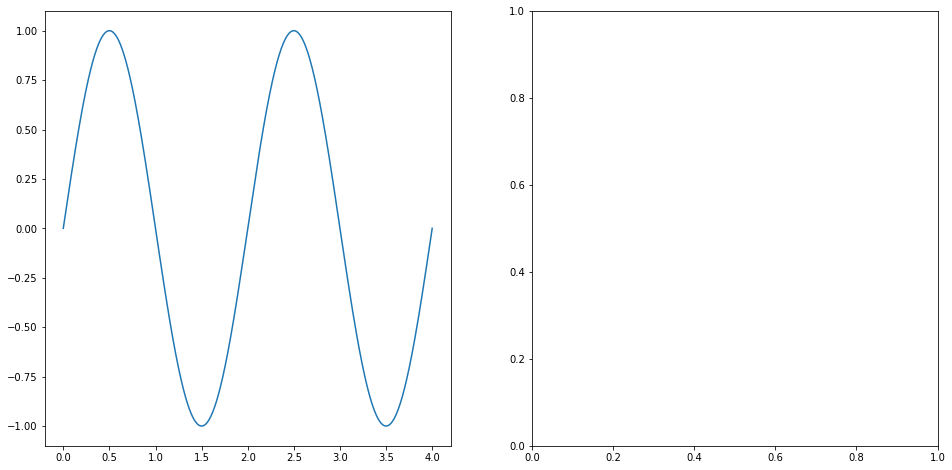

In [47]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
xt = np.linspace(0, 4, 1000)
y = np.sin(xt*np.pi)
plt.plot(xt, y)
plt.subplot(1,2,2)
# freq=1
# complex_y = y * np.exp(-2 * np.pi * 1j * freq * xt) #using imaginary j  and exp to convert to polar
# plt.plot(complex_y.real, complex_y.imag)

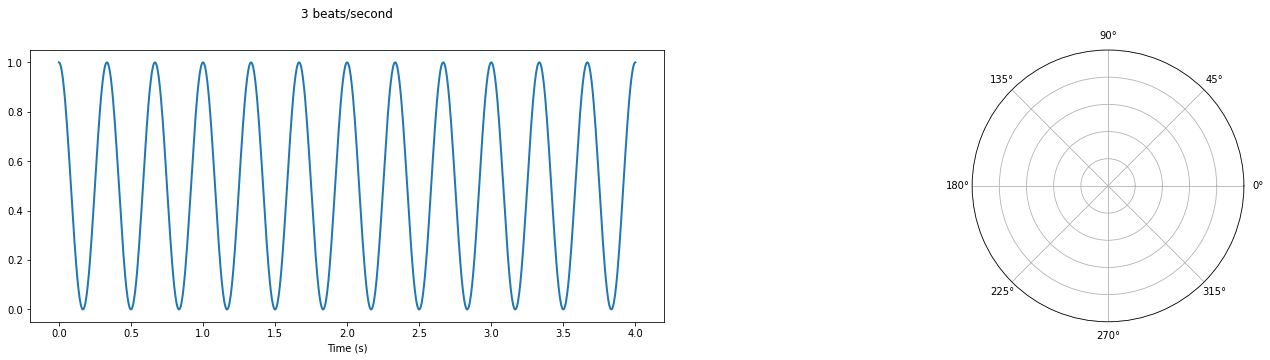

In [3]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
xt = np.linspace(0,4,1000)
y = (np.cos(xt*3*2*np.pi)+1)/2
plt.plot(xt,y,lw=2)
plt.gca().set_title('3 beats/second',y=1.1)
plt.gca().set_xlabel('Time (s)') 
plt.subplot(1,2,2, polar=True)
_=plt.gca().set_yticklabels([])

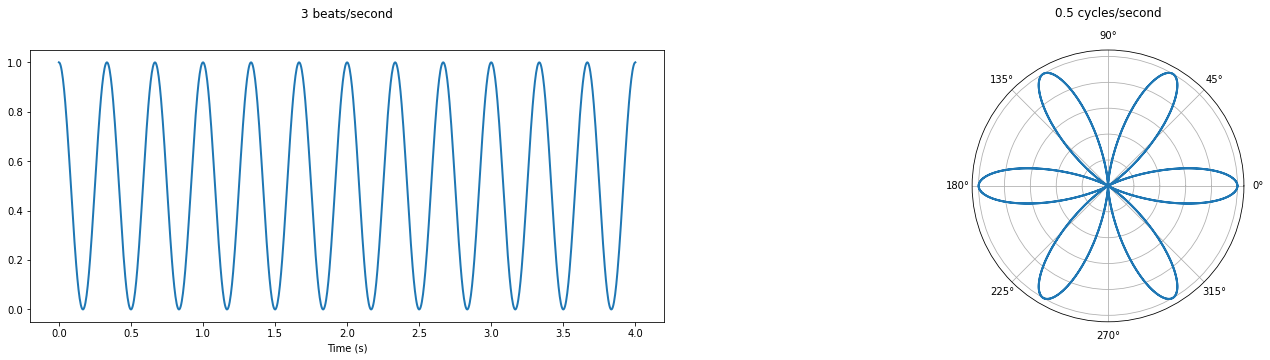

In [4]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
xt = np.linspace(0,4,1000)
y = (np.cos(xt*3*2*np.pi)+1)/2
plt.plot(xt,y,lw=2)
plt.gca().set_title('3 beats/second',y=1.1)
plt.gca().set_xlabel('Time (s)')
plt.subplot(1,2,2, polar=True)
plt.plot(xt*.5*2*np.pi,y,alpha=1,lw=2)
plt.gca().set_yticklabels([])
_=plt.gca().set_title('0.5 cycles/second',y=1.1)

Some set up to cycle through different frequencies:

In [5]:
%%capture
import time
import pylab as pl
from IPython import display
xt = np.linspace(0,4,1000)
y = (np.cos(xt*3*2*np.pi)+1)/2
y = (np.cos(xt*3*2*np.pi)+1)/4+(np.cos(xt*2*2*np.pi)+1)/4
plt.gca().set_title('3 beats/second',y=1.1)
plt.gca().set_xlabel('Time (s)')

Wrapping the signal (left) around the unit circle (right) at different frequencies:

Text(0.5, 1.1, '5 cycles/second')

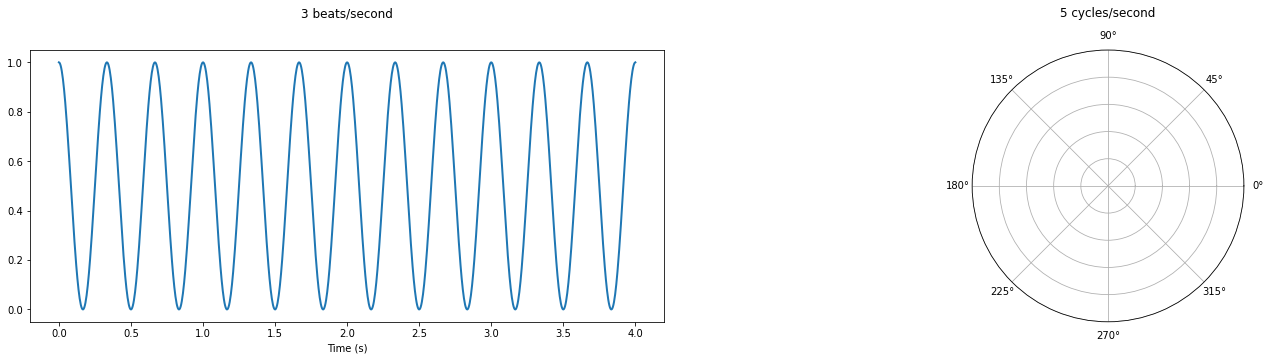

In [14]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
xt = np.linspace(0,4,1000)
y = (np.cos(xt*3*2*np.pi)+1)/2
plt.plot(xt,y,lw=2)
plt.gca().set_title('3 beats/second',y=1.1)
plt.gca().set_xlabel('Time (s)')
plt.subplot(1,2,2, polar=True)
# plt.plot(xt*.5*2*np.pi,y,alpha=1)
# plt.plot(xt*5*2*np.pi,y)
plt.gca().set_yticklabels([])
plt.gca().set_title('5 cycles/second',y=1.1)

Text(0.5, 1.1, '3 cycles/second')

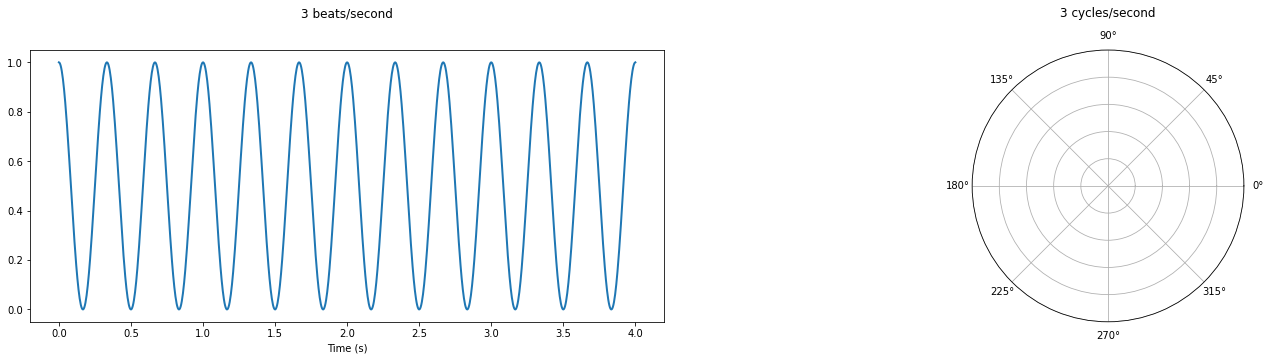

In [15]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
xt = np.linspace(0,4,1000)
y = (np.cos(xt*3*2*np.pi)+1)/2
plt.plot(xt,y,lw=2)
plt.gca().set_title('3 beats/second',y=1.1)
plt.gca().set_xlabel('Time (s)')
plt.subplot(1,2,2, polar=True)
# plt.plot(xt*.5*2*np.pi,y,alpha=1) #add back
# plt.plot(xt*5*2*np.pi,y,alpha=1)
# plt.plot(xt*3*2*np.pi,y)
plt.gca().set_yticklabels([])
plt.gca().set_title('3 cycles/second',y=1.1)

Text(0.5, 1.1, '3 cycles/second')

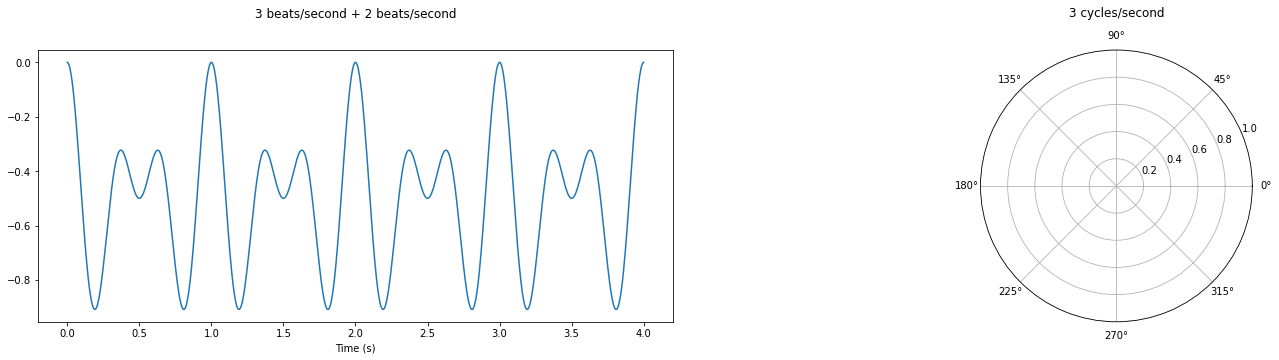

In [16]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
xt = np.linspace(0,4,1000)
y = -1 + (np.cos(xt*3*2*np.pi)+1)/4+(np.cos(xt*2*2*np.pi)+1)/4
plt.plot(xt,y)
plt.gca().set_title('3 beats/second + 2 beats/second',y=1.1)
plt.gca().set_xlabel('Time (s)')
plt.subplot(1,2,2, polar=True)
# plt.polar(xt*.5*2*np.pi,y,label='0.5 c/s')
# plt.polar(xt*2*2*np.pi,y,label='2 c/s')
# plt.plot(xt*.01*2*np.pi,y,label='3 c/s')
# plt.gca().set_yticklabels([])
# plt.legend(loc='lower right',fontsize=10,bbox_to_anchor=(1.3, -.1))
plt.gca().set_title('3 cycles/second',y=1.1)

In [ ]:
for i in np.linspace(.1,6,100):
    fig=plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    plt.plot(xt,y,lw=2)
    plt.subplot(1,2,2, polar=True)
    display.clear_output(wait=True)
    plt.plot(xt*i*2*np.pi,y,alpha=1,lw=2)
    plt.gca().set_yticklabels([])
    _=plt.gca().set_title(f'{i:.2f} cycles/second',y=1.1) 
    display.display(pl.gcf())
    time.sleep(.25)

(0.0, 10.0)

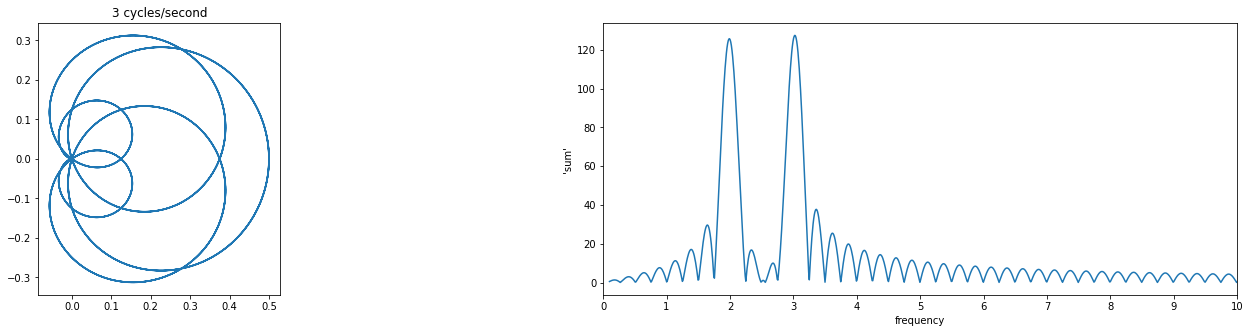

In [17]:
plt.figure(figsize=(25, 5))
plt.subplot(1, 2, 1)
xt = np.linspace(0, 4, 1000)
y = (np.cos(xt * 3 * 2 * np.pi) + 1) / 4 + (np.cos(xt * 2 * 2 * np.pi) + 1) / 4 - .5
complex_y = y * np.exp(-2 * np.pi * 1j * 3 * xt) #using imaginary j  and exp to convert to polar
plt.plot(complex_y.real, complex_y.imag)
plt.gca().set_aspect(1); plt.gca().set_title("3 cycles/second"); plt.subplot(1, 2, 2)
x_COM = []
freqs = np.linspace(0.1, 10, 1000)
# freqs = np.arange(0,1000-1)
for i in freqs:
    complex_y = y * np.exp(-2 * np.pi * 1j * i * xt)
    x_COM.append((np.sum(complex_y.real)**2+np.sum(complex_y.imag)**2)**(1/2))
     
plt.plot(freqs, x_COM,alpha=1,zorder=2); _ = plt.gca().set_xticks(range(0, 11)); plt.gca().set_ylabel("'sum'"); plt.gca().set_xlabel("frequency", y=1.1)
plt.gca().set_xlim([0,10])